# Bermuda Options

A **Bermuda option** sits between a European and an American option in terms of exercise flexibility:

| Style | Exercise window |
|---|---|
| European | Only at expiry |
| Bermuda | On a fixed set of pre-specified dates |
| American | Any time up to expiry |

This intermediate structure appears frequently in practice — callable bonds, certain swaptions, and structured products all embed Bermuda-style optionality.

## Pricing approach

`BermudaOption` uses a **Cox-Ross-Rubinstein (CRR) binomial tree** identical to the American tree, except early exercise is only permitted at the nodes that correspond to the specified exercise dates. At all other nodes the holder must continue.

The resulting pricing hierarchy is:

$$P_{\text{European}} \le P_{\text{Bermuda}} \le P_{\text{American}}$$

As exercise dates are added, the Bermuda price rises monotonically toward the American price.

In [1]:
from neon.lib.instruments.options.option_inputs import OptionInputs
from neon.lib.instruments.options.option_type import OptionType
from neon.lib.instruments.options.bermuda import BermudaOption
from neon.lib.instruments.options.american import AmericanOption
from neon.lib.instruments.options.european import EuropeanOption
from neon.lib.greeks.analytical_greeks import AnalyticalGreeks
import matplotlib.pyplot as plt

## 1. Base inputs

All three option styles share the same market parameters so the prices are directly comparable.

In [2]:
common = dict(
    underlying_ticker="DEMO",
    underlying_price=100.0,
    strike_price=100.0,
    volatility=0.20,
    risk_free_rate=0.05,
    current_date="20250101",
    expiry_date="20260101",
    option_type=OptionType.Put,
)

inputs = OptionInputs(**common)

## 2. Price comparison: European, Bermuda, American

The Bermuda option here has two exercise dates — mid-year (2025-07-01) and expiry (2026-01-01).

In [3]:
exercise_dates_2 = ["20250701", "20260101"]

european = EuropeanOption(inputs, AnalyticalGreeks())
bermuda  = BermudaOption(inputs, exercise_dates=exercise_dates_2)
american = AmericanOption(inputs)

p_eur = european.price()
p_ber = bermuda.price()
p_ame = american.price()

print(f"European put : {p_eur:.4f}")
print(f"Bermuda put  : {p_ber:.4f}  (exercise dates: {exercise_dates_2})")
print(f"American put : {p_ame:.4f}")

European put : 5.5735
Bermuda put  : 5.8341  (exercise dates: ['20250701', '20260101'])
American put : 6.0872


## 3. Pricing hierarchy: European ≤ Bermuda ≤ American

We verify the inequality and visualise the spread between the three styles.

Hierarchy confirmed: European ≤ Bermuda ≤ American


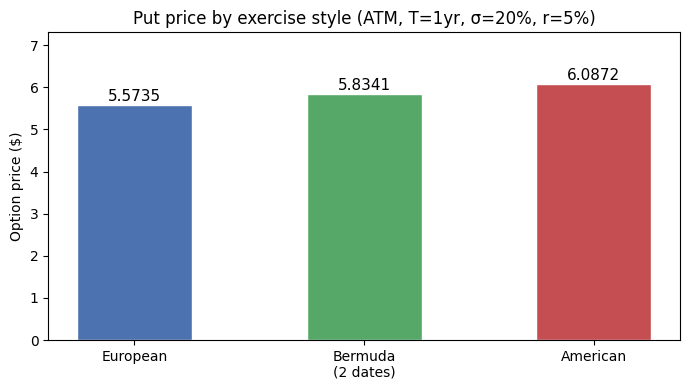

In [4]:
assert p_eur <= p_ber + 1e-8, "Expected European ≤ Bermuda"
assert p_ber <= p_ame + 1e-8, "Expected Bermuda ≤ American"
print("Hierarchy confirmed: European ≤ Bermuda ≤ American")

labels = ["European", "Bermuda\n(2 dates)", "American"]
prices = [p_eur, p_ber, p_ame]
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, prices, color=colors, width=0.5, edgecolor="white")
for bar, price in zip(bars, prices):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{price:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )
ax.set_ylabel("Option price ($)")
ax.set_title("Put price by exercise style (ATM, T=1yr, σ=20%, r=5%)")
ax.set_ylim(0, max(prices) * 1.2)
plt.tight_layout()
plt.show()

## 4. Effect of number of exercise dates

We price the Bermuda put with 1, 2, and 3 exercise dates spread evenly across the option's life. As exercise dates are added the Bermuda price converges toward the American price.

In [5]:
# Exercise-date schedules (each set includes the final expiry so the tree always reaches expiry)
schedules = {
    1: ["20260101"],                                      # expiry only
    2: ["20250701", "20260101"],                          # mid-year + expiry
    3: ["20250401", "20250701", "20260101"],              # quarterly + expiry
}

results = {}
for n_dates, dates in schedules.items():
    opt = BermudaOption(inputs, exercise_dates=dates)
    results[n_dates] = opt.price()
    print(f"{n_dates} exercise date(s): {results[n_dates]:.4f}  {dates}")

print(f"\nFor reference — American: {p_ame:.4f}  |  European: {p_eur:.4f}")

1 exercise date(s): 5.5656  ['20260101']
2 exercise date(s): 5.8341  ['20250701', '20260101']
3 exercise date(s): 5.8745  ['20250401', '20250701', '20260101']

For reference — American: 6.0872  |  European: 5.5735


## 5. Plot: price vs. number of exercise dates

The dashed horizontal lines show the European and American bounds.

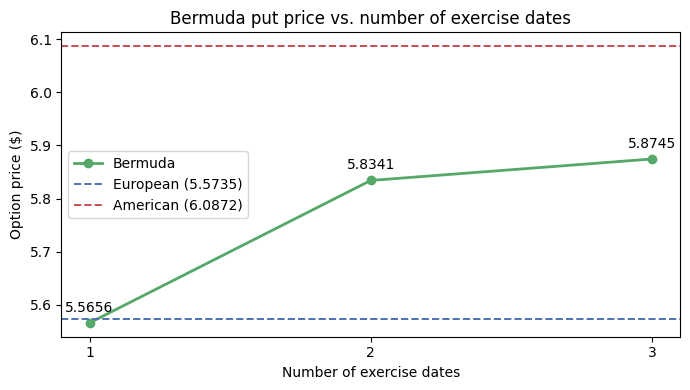

In [6]:
n_list = sorted(results)
p_list = [results[n] for n in n_list]

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(n_list, p_list, marker="o", linewidth=2, color="#55A868", label="Bermuda")
ax.axhline(p_eur, linestyle="--", color="#4C72B0", linewidth=1.4, label=f"European ({p_eur:.4f})")
ax.axhline(p_ame, linestyle="--", color="#C44E52", linewidth=1.4, label=f"American ({p_ame:.4f})")

for x, y in zip(n_list, p_list):
    ax.annotate(f"{y:.4f}", xy=(x, y), xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=10)

ax.set_xlabel("Number of exercise dates")
ax.set_ylabel("Option price ($)")
ax.set_title("Bermuda put price vs. number of exercise dates")
ax.set_xticks(n_list)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

- With **1 exercise date** (expiry only) the Bermuda price equals the European price — there is no early exercise advantage.
- Each additional exercise date raises the price by giving the holder more opportunities to exercise optimally when it is in the money.
- The price approaches the American price as the number of dates grows, but never exceeds it.
- The spread between European and American prices sets the maximum value that Bermuda flexibility can add.